# Machine Learning Classification of Glioma Using Clinical and Genetic Mutation Data

**A proof-of-concept comparison of Logistic Regression and Random Forest for LGG vs GBM classification**

## Project Overview

This project explores whether clinical characteristics and genetic mutation features can be used to distinguish **lower-grade glioma (LGG)** from **glioblastoma (GBM)** using supervised machine learning.

The workflow uses a public glioma dataset from the **UCI Machine Learning Repository**, derived from TCGA glioma projects. Two classification approaches are compared:

- **Logistic Regression** — a relatively simple and interpretable baseline classifier
- **Random Forest** — an ensemble model capable of learning nonlinear relationships

Model performance is evaluated using a held-out test set, 10-fold stratified cross-validation, accuracy, balanced accuracy, ROC-AUC, precision, recall, and F1-score. Permutation importance is then used to examine which input features the selected model relies on most.

> **Important:** This is a retrospective proof-of-concept and is not a clinical diagnostic tool.

### Main question

**Can age, gender, and mutation profiles distinguish LGG from GBM in this public dataset?**

### Workflow

`Raw UCI/TCGA data → cleaning → feature selection → 80/20 train-test split → preprocessing → Logistic Regression & Random Forest → validation → feature importance → biological interpretation`


## 1. Setup and Data Loading

The analysis was completed in **Google Colab** using Python, pandas, NumPy, matplotlib, and scikit-learn.

To reproduce the notebook, download `TCGA_GBM_LGG_Mutations_all.csv` from the UCI Glioma Grading Clinical and Mutation Features dataset, run the upload cell below, and select the CSV file.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from google.colab import files

uploaded = files.upload()

Saving TCGA_GBM_LGG_Mutations_all.csv to TCGA_GBM_LGG_Mutations_all (1).csv


In [5]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("File loaded:", filename)
print("Dataset size:", df.shape)

display(df.head())

File loaded: TCGA_GBM_LGG_Mutations_all (1).csv
Dataset size: (862, 27)


,Grade,Project,Case_ID,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,LGG,TCGA-LGG,TCGA-DU-8164,Male,51 years 108 days,"Oligodendroglioma, NOS",white,MUTATED,NOT_MUTATED,NOT_MUTATED,...,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,LGG,TCGA-LGG,TCGA-QH-A6CY,Male,38 years 261 days,Mixed glioma,white,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
2,LGG,TCGA-LGG,TCGA-HW-A5KM,Male,35 years 62 days,"Astrocytoma, NOS",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,LGG,TCGA-LGG,TCGA-E1-A7YE,Female,32 years 283 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
4,LGG,TCGA-LGG,TCGA-S9-A6WG,Male,31 years 187 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


## 2. Initial Data Inspection

The raw CSV contains **862 records and 27 columns** in this analysis. The target column is `Grade`, with two classes: **LGG** and **GBM**.

Before modeling, the dataset is inspected for class balance, duplicate case identifiers, and special missing-value markers.


In [6]:
print(df.columns.tolist())

['Grade', 'Project', 'Case_ID', 'Gender', 'Age_at_diagnosis', 'Primary_Diagnosis', 'Race', 'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']


In [7]:
df["Grade"].value_counts()

,count
Grade,
LGG,499
GBM,363


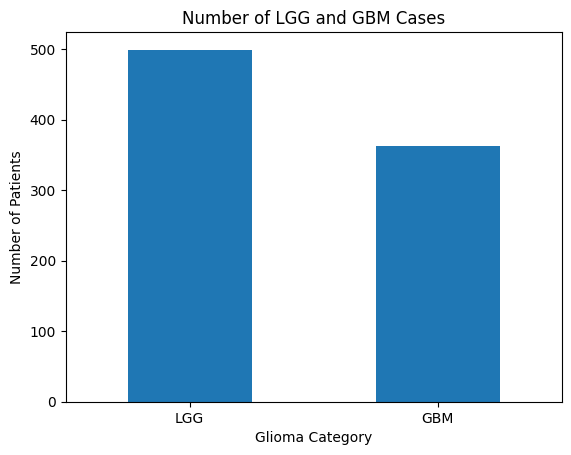

In [8]:
df["Grade"].value_counts().plot(kind="bar")

plt.title("Number of LGG and GBM Cases")
plt.xlabel("Glioma Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

In [9]:
print("Number of unique Case IDs:")
print(df["Case_ID"].nunique())

print()

print("Number of duplicate Case IDs:")
print(df["Case_ID"].duplicated().sum())

Number of unique Case IDs:
862

Number of duplicate Case IDs:
0


## 3. Data Cleaning

The raw file uses `--` as a missing-value marker in several clinical columns. These values are converted to proper `NaN` values so that missing data can be handled explicitly rather than accidentally interpreted as meaningful values.

This step is important because, for example, an unknown age should **not** become an age of zero.


In [10]:
for column in df.columns:
    count = (df[column].astype(str).str.strip() == "--").sum()

    if count > 0:
        print(column, ":", count)

Gender : 4
Age_at_diagnosis : 5
Primary_Diagnosis : 4
Race : 4


In [11]:
df = df.replace("--", np.nan)

In [12]:
print(df.isnull().sum())

Grade                0
Project              0
Case_ID              0
Gender               4
Age_at_diagnosis     5
Primary_Diagnosis    4
Race                 4
IDH1                 0
TP53                 0
ATRX                 0
PTEN                 0
EGFR                 0
CIC                  0
MUC16                0
PIK3CA               0
NF1                  0
PIK3R1               0
FUBP1                0
RB1                  0
NOTCH1               0
BCOR                 0
CSMD3                0
SMARCA4              0
GRIN2A               0
IDH2                 0
FAT4                 0
PDGFRA               0
dtype: int64


## 4. Target Definition and Feature Selection

The target is encoded as:

- `0 = LGG`
- `1 = GBM`

Several raw columns are deliberately excluded from the predictor matrix:

- `Grade` — this is the outcome being predicted.
- `Project` — values such as `TCGA-LGG` and `TCGA-GBM` would directly reveal the class and create **data leakage**.
- `Case_ID` — an identifier rather than a biological predictor.
- `Primary_Diagnosis` — existing diagnostic information is too closely related to the target for this proof-of-concept question.
- `Race` — excluded from this educational model rather than casually treating race as a direct tumor-biological predictor.

The resulting predictors consist of **age at diagnosis, gender, and mutation-status variables**.


In [13]:
y = df["Grade"].map({
    "LGG": 0,
    "GBM": 1
})

In [14]:
X = df.drop(
    columns=[
        "Grade",
        "Project",
        "Case_ID",
        "Primary_Diagnosis",
        "Race"
    ]
).copy()

## 5. Converting Age to a Numerical Feature

`Age_at_diagnosis` is stored as text such as `51 years 108 days`. It is converted to decimal years so it can be used as a numerical model input. Missing ages remain missing and are imputed later using the median of the training data.


In [15]:
def convert_age_to_years(age_text):

    if pd.isna(age_text):
        return np.nan

    age_text = str(age_text).strip()

    years = 0
    days = 0

    if "years" in age_text:
        years = int(age_text.split(" years")[0])

    if "days" in age_text:
        day_part = age_text.split(" years ")[1]
        days = int(day_part.split(" days")[0])

    return years + (days / 365)

In [16]:
X["Age_at_diagnosis"] = X["Age_at_diagnosis"].apply(
    convert_age_to_years
)

In [17]:
print(X["Age_at_diagnosis"].describe())
print()
print("Missing ages:", X["Age_at_diagnosis"].isnull().sum())

count    857.000000
mean      50.924471
std       15.732797
min       14.421918
25%       38.021918
50%       51.550685
75%       62.769863
max       89.287671
Name: Age_at_diagnosis, dtype: float64

Missing ages: 5


In [18]:
print(X.dtypes)

Gender               object
Age_at_diagnosis    float64
IDH1                 object
TP53                 object
ATRX                 object
PTEN                 object
EGFR                 object
CIC                  object
MUC16                object
PIK3CA               object
NF1                  object
PIK3R1               object
FUBP1                object
RB1                  object
NOTCH1               object
BCOR                 object
CSMD3                object
SMARCA4              object
GRIN2A               object
IDH2                 object
FAT4                 object
PDGFRA               object
dtype: object


## 6. Train/Test Split

The dataset is divided into:

- **80% training data** — used to develop the models
- **20% held-out test data** — reserved for final evaluation

`stratify=y` preserves approximately the same LGG/GBM proportions in the training and test groups. `random_state=42` makes the split reproducible.


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training patients:", len(X_train))
print("Testing patients:", len(X_test))

Training patients: 689
Testing patients: 173


In [20]:
print("TRAINING SET:")
print(y_train.value_counts())
print()
print("TEST SET:")
print(y_test.value_counts())

TRAINING SET:
Grade
0    399
1    290
Name: count, dtype: int64

TEST SET:
Grade
0    100
1     73
Name: count, dtype: int64


## 7. Preprocessing Pipeline

The preprocessing is performed **inside a scikit-learn pipeline**, which helps prevent information from the test set leaking into training.

### Numerical feature
`Age_at_diagnosis`
- missing values → median imputation
- values → standardized with `StandardScaler`

### Categorical features
Gender and mutation-status variables
- missing values → most frequent category
- categories → converted into numerical indicators using one-hot encoding

The same preprocessing framework is used for both models.


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [22]:
numeric_features = ["Age_at_diagnosis"]

categorical_features = [
    column for column in X.columns
    if column != "Age_at_diagnosis"
]

In [23]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [24]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

## 8. Model 1 — Logistic Regression

Logistic Regression is used as the interpretable baseline classifier. The model learns statistical relationships between the input variables and the probability of belonging to the GBM class.

`class_weight="balanced"` is used so that class frequency is taken into account during training.


In [26]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [27]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age_at_diagnosis']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'IDH1', 'TP53',
                                                   'ATRX', 'PTEN', 'EGFR',
                                                   'CIC', 'MUC16', 'PIK3CA',
                                                   'NF1', 'PIK3R1', 'FUBP1',
                                                   'RB1', 'NOTCH1', 'BCOR',
                                                   'CSMD3', 'SMARCA4', 'GRIN2A',
                                                   'IDH2', 'FAT4',
                                                   'PDGFRA'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    random_state=42))])

In [28]:
predictions = logistic_model.predict(X_test)

### Logistic Regression — Held-Out Test Performance

The model is evaluated on patients that were not used for training. Accuracy gives the proportion classified correctly, while balanced accuracy gives equal weight to performance in both classes.


In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.8670520231213873
Accuracy percentage: 86.71 %


In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[84 16]
 [ 7 66]]


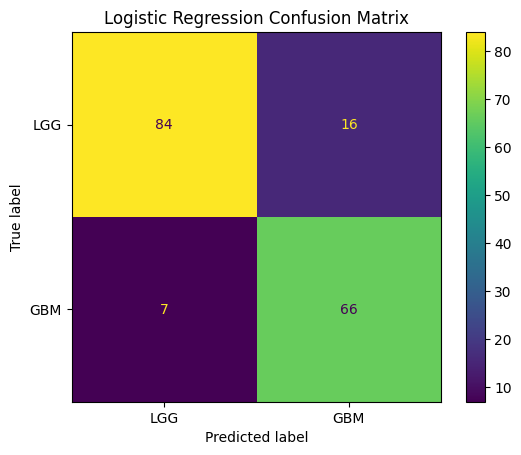

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["LGG", "GBM"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions,
        target_names=["LGG", "GBM"],
        digits=3
    )
)

              precision    recall  f1-score   support

         LGG      0.923     0.840     0.880       100
         GBM      0.805     0.904     0.852        73

    accuracy                          0.867       173
   macro avg      0.864     0.872     0.866       173
weighted avg      0.873     0.867     0.868       173



In [33]:
from sklearn.metrics import balanced_accuracy_score

balanced_accuracy = balanced_accuracy_score(
    y_test,
    predictions
)

print("Regular accuracy:", round(accuracy, 3))
print("Balanced accuracy:", round(balanced_accuracy, 3))

Regular accuracy: 0.867
Balanced accuracy: 0.872


### Prediction Probabilities and ROC-AUC

Rather than using only hard LGG/GBM labels, the classifier also produces a probability of GBM. These probabilities are used to calculate ROC-AUC, a threshold-independent measure of discrimination.

An ROC-AUC of 0.5 represents approximately random discrimination; larger values indicate stronger separation of the two classes.


In [34]:
gbm_probabilities = logistic_model.predict_proba(X_test)[:, 1]

print(gbm_probabilities[:10])

[0.0297185  0.88048115 0.02596481 0.01360164 0.04019914 0.08008356
 0.90587764 0.06087742 0.80225557 0.03523577]


In [35]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions,
    "Probability_of_GBM": gbm_probabilities
})

comparison["Actual"] = comparison["Actual"].map({
    0: "LGG",
    1: "GBM"
})

comparison["Predicted"] = comparison["Predicted"].map({
    0: "LGG",
    1: "GBM"
})

comparison["Correct"] = (
    comparison["Actual"] == comparison["Predicted"]
)

display(comparison.head(20))

,Actual,Predicted,Probability_of_GBM,Correct
0,LGG,LGG,0.029718,True
1,GBM,GBM,0.880481,True
2,LGG,LGG,0.025965,True
3,LGG,LGG,0.013602,True
4,LGG,LGG,0.040199,True
5,LGG,LGG,0.080084,True
6,LGG,GBM,0.905878,False
7,LGG,LGG,0.060877,True
8,GBM,GBM,0.802256,True
9,LGG,LGG,0.035236,True


In [36]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    gbm_probabilities
)

print("ROC-AUC:", round(roc_auc, 3))

ROC-AUC: 0.9


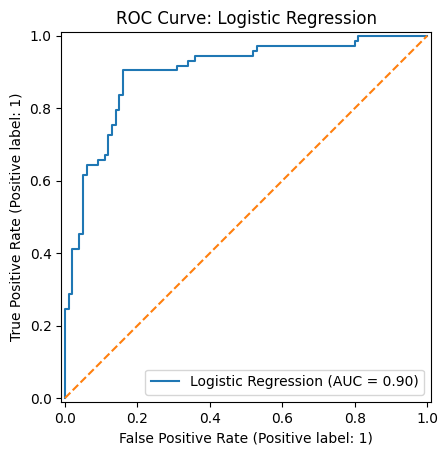

In [37]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    gbm_probabilities,
    name="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve: Logistic Regression")
plt.show()

### 10-Fold Stratified Cross-Validation

Cross-validation is performed **within the training set**. The training data are divided into 10 folds; each fold serves as validation data once while the other nine are used for training. Averaging across folds gives a more stable estimate of model performance than relying on a single split.


In [38]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [39]:
cv_results = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "roc_auc": "roc_auc"
    }
)

In [40]:
print(
    "Mean CV Accuracy:",
    round(cv_results["test_accuracy"].mean(), 3)
)

print(
    "Mean CV Balanced Accuracy:",
    round(cv_results["test_balanced_accuracy"].mean(), 3)
)

print(
    "Mean CV ROC-AUC:",
    round(cv_results["test_roc_auc"].mean(), 3)
)

print(
    "CV ROC-AUC Standard Deviation:",
    round(cv_results["test_roc_auc"].std(), 3)
)

Mean CV Accuracy: 0.883
Mean CV Balanced Accuracy: 0.89
Mean CV ROC-AUC: 0.93
CV ROC-AUC Standard Deviation: 0.027


## 9. Model 2 — Random Forest

Random Forest combines many decision trees and can capture nonlinear relationships and interactions. The purpose of including it is to test whether a more complex model provides a meaningful advantage over the simpler Logistic Regression baseline.


In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [43]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age_at_diagnosis']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'IDH1', 'TP53',
                                                   'ATRX', 'PTEN', 'EGFR',
                                                   'CIC', 'MUC16', 'PIK3CA',
                                                   'NF1', 'PIK3R1', 'FUBP1',
                                                   'RB1', 'NOTCH1', 'BCOR',
                                                   'CSMD3', 'SMARCA4', 'GRIN2A',
                                                   'IDH2', 'FAT4',
                                                   'PDGFRA'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=2, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [44]:
rf_predictions = random_forest_model.predict(X_test)

In [45]:
rf_gbm_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

In [46]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_balanced_accuracy = balanced_accuracy_score(
    y_test,
    rf_predictions
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_gbm_probabilities
)

print("Random Forest Accuracy:", round(rf_accuracy, 3))
print("Random Forest Balanced Accuracy:", round(rf_balanced_accuracy, 3))
print("Random Forest ROC-AUC:", round(rf_roc_auc, 3))

Random Forest Accuracy: 0.844
Random Forest Balanced Accuracy: 0.848
Random Forest ROC-AUC: 0.909


In [47]:
rf_cv_results = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "roc_auc": "roc_auc"
    }
)

In [48]:
print(
    "RF Mean CV Accuracy:",
    round(rf_cv_results["test_accuracy"].mean(), 3)
)

print(
    "RF Mean CV Balanced Accuracy:",
    round(rf_cv_results["test_balanced_accuracy"].mean(), 3)
)

print(
    "RF Mean CV ROC-AUC:",
    round(rf_cv_results["test_roc_auc"].mean(), 3)
)

print(
    "RF CV ROC-AUC Standard Deviation:",
    round(rf_cv_results["test_roc_auc"].std(), 3)
)

RF Mean CV Accuracy: 0.874
RF Mean CV Balanced Accuracy: 0.882
RF Mean CV ROC-AUC: 0.929
RF CV ROC-AUC Standard Deviation: 0.023


## 10. Model Comparison

The two models are compared using the same held-out test set and the same 10-fold cross-validation framework.


In [49]:
results_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Test Accuracy": [
        accuracy,
        rf_accuracy
    ],

    "Test Balanced Accuracy": [
        balanced_accuracy,
        rf_balanced_accuracy
    ],

    "Test ROC-AUC": [
        roc_auc,
        rf_roc_auc
    ],

    "CV ROC-AUC Mean": [
        cv_results["test_roc_auc"].mean(),
        rf_cv_results["test_roc_auc"].mean()
    ],

    "CV ROC-AUC SD": [
        cv_results["test_roc_auc"].std(),
        rf_cv_results["test_roc_auc"].std()
    ]
})

display(results_table.round(3))

,Model,Test Accuracy,Test Balanced Accuracy,Test ROC-AUC,CV ROC-AUC Mean,CV ROC-AUC SD
0,Logistic Regression,0.867,0.872,0.900,0.930,0.027
1,Random Forest,0.844,0.848,0.909,0.929,0.023


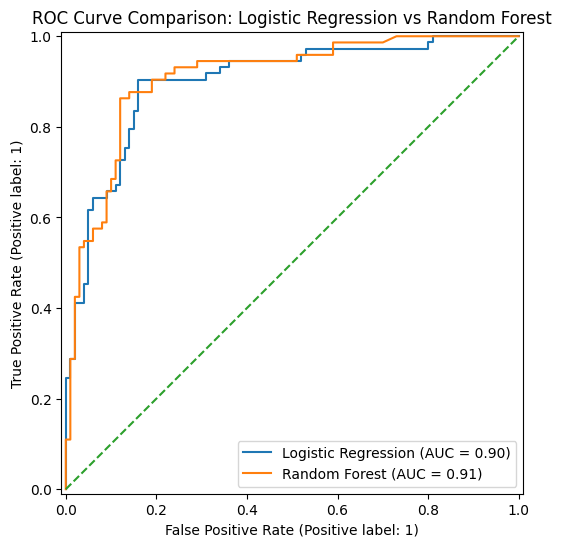

In [50]:
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    gbm_probabilities,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_gbm_probabilities,
    name="Random Forest",
    ax=ax
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve Comparison: Logistic Regression vs Random Forest")
plt.show()

### Interpretation of Model Comparison

In this run:

| Metric | Logistic Regression | Random Forest |
|---|---:|---:|
| Test accuracy | **0.867** | 0.844 |
| Test balanced accuracy | **0.872** | 0.848 |
| Test ROC-AUC | 0.900 | **0.909** |
| Mean CV ROC-AUC | **0.930** | 0.929 |
| CV ROC-AUC SD | 0.027 | **0.023** |

Both models demonstrated strong discrimination within this dataset. Random Forest had a slightly higher held-out ROC-AUC, while Logistic Regression had higher test accuracy and balanced accuracy. Cross-validation ROC-AUC was essentially identical.

**Key takeaway:** the more complex Random Forest did not show a clear overall advantage over the simpler Logistic Regression model.


## 11. Permutation Feature Importance

Permutation importance is applied to the Logistic Regression pipeline. One feature is randomly shuffled at a time, breaking its relationship with the correct patients. The resulting decrease in ROC-AUC indicates how strongly the trained model depended on that feature.

This is a measure of **predictive importance**, not biological causation.


In [51]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(
    logistic_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=25,
    random_state=42,
    n_jobs=-1
)

In [52]:
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance.importances_mean,
    "Standard Deviation": importance.importances_std
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(importance_df.head(15))

,Feature,Importance,Standard Deviation
0,IDH1,0.237660,0.037877
1,Age_at_diagnosis,0.017967,0.009727
2,NOTCH1,0.008066,0.005624
3,TP53,0.007178,0.006834
4,GRIN2A,0.005375,0.003529
5,PTEN,0.004707,0.003613
6,NF1,0.003567,0.003273
7,IDH2,0.002893,0.004913
8,MUC16,0.002142,0.003009
9,PDGFRA,0.001458,0.001200


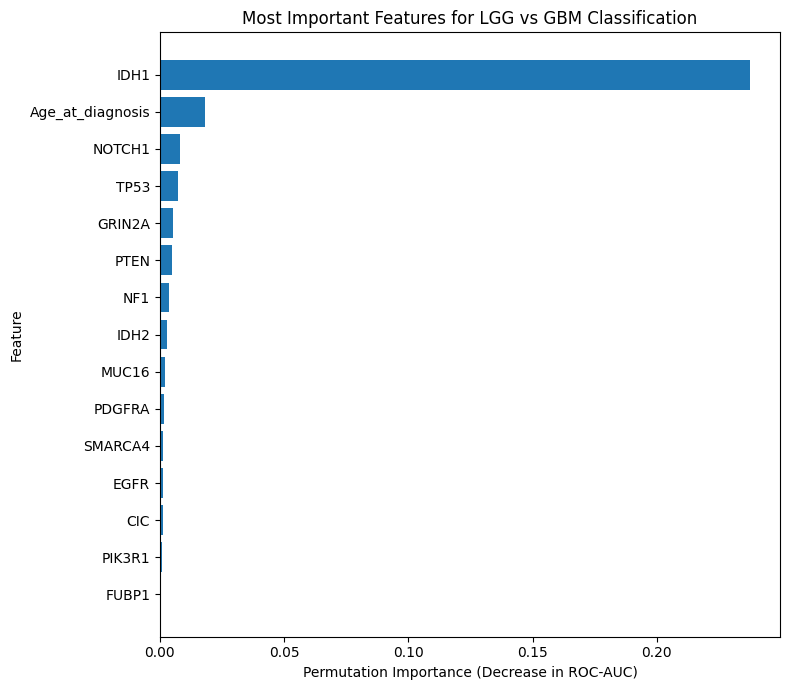

In [53]:
top_features = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(8, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Permutation Importance (Decrease in ROC-AUC)")
plt.ylabel("Feature")
plt.title("Most Important Features for LGG vs GBM Classification")

plt.tight_layout()
plt.show()

### Feature-Importance Interpretation

`IDH1` was by far the strongest individual predictive feature in this analysis, with a mean permutation importance of approximately **0.238**. The next-ranked feature, age at diagnosis, had a much smaller importance of approximately **0.018**, followed by NOTCH1 and TP53.

This result should be phrased carefully:

> **IDH1 mutation status was the strongest individual predictive feature for distinguishing the LGG and GBM labels in this trained model and dataset.**

It does **not** establish that IDH1 causes either tumor category, nor does it rank the universal biological importance of genes in glioma.


## 12. Results Summary

The Logistic Regression classifier achieved:

- **86.7% test accuracy**
- **87.2% balanced accuracy**
- **0.900 held-out test ROC-AUC**
- **0.930 ± 0.027 mean 10-fold cross-validation ROC-AUC**

Its confusion matrix was:

- 84 LGG cases correctly classified as LGG
- 16 LGG cases classified as GBM
- 7 GBM cases classified as LGG
- 66 GBM cases correctly classified as GBM

The Random Forest achieved:

- **84.4% test accuracy**
- **84.8% balanced accuracy**
- **0.909 held-out test ROC-AUC**
- **0.929 ± 0.023 mean 10-fold cross-validation ROC-AUC**

Overall, both algorithms performed similarly. The simpler Logistic Regression model remained highly competitive with Random Forest.


## 13. Discussion

Several aspects of the analysis are particularly informative:

1. **Validation matters.** A held-out test set and cross-validation were used rather than evaluating a model on the same cases used to train it.
2. **Data leakage matters.** `Project` was removed because it directly encodes the LGG/GBM source project and would make the prediction task artificially easy.
3. **Complexity did not guarantee better performance.** Random Forest produced only a small ROC-AUC advantage on the held-out set and lower accuracy, while cross-validation performance was almost identical.
4. **Interpretability adds biological context.** Permutation importance showed that IDH1 carried much more predictive information than any other individual feature in this model.
5. **Prediction is not causation.** The machine-learning results identify statistical patterns within this dataset; they do not prove biological mechanisms.


## 14. Limitations

This project has several important limitations:

- It is a retrospective proof-of-concept based on one public dataset.
- The held-out test cases come from the same overall dataset as the training cases; there is no independent external cohort.
- LGG-versus-GBM classification simplifies the molecular complexity of contemporary glioma classification.
- Performance estimates depend on the dataset, preprocessing choices, and train/test split.
- Permutation importance measures how much the model depends on a feature for prediction; it does not establish causation or clinical importance.
- No prospective clinical validation, calibration study, or regulatory evaluation was performed.

Therefore, the model should **not** be interpreted or used as a clinical diagnostic system.


## 15. Conclusion

This project demonstrates an end-to-end biomedical machine-learning workflow using clinical and genetic mutation data to distinguish LGG from GBM.

Both Logistic Regression and Random Forest showed strong discriminatory performance, with held-out ROC-AUC values around 0.90 and cross-validation ROC-AUC values around 0.93. The simpler Logistic Regression model performed comparably to Random Forest across the overall evaluation.

**Permutation importance identified IDH1 mutation status as the dominant individual predictive feature in the Logistic Regression model.**

The project highlights that successful biomedical machine learning involves more than fitting an algorithm: careful data cleaning, avoiding leakage, appropriate validation, model comparison, and cautious interpretation are central to meaningful analysis.


## 16. Tools

- Python
- pandas
- NumPy
- scikit-learn
- matplotlib
- Google Colab

## 17. References

**Dataset**

Tasci, E., Camphausen, K., Krauze, A. V., & Zhuge, Y. (2022). *Glioma Grading Clinical and Mutation Features* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5R62J

UCI dataset page:  
https://archive.ics.uci.edu/dataset/759/glioma+grading+clinical+and+mutation+features+dataset

**Associated study**

Tasci, E., Zhuge, Y., Kaur, H., Camphausen, K., & Krauze, A. V. (2022). Hierarchical voting-based feature selection and ensemble learning model scheme for glioma grading with clinical and molecular characteristics. *International Journal of Molecular Sciences, 23*(22), 14155. https://doi.org/10.3390/ijms232214155

**Machine-learning software**

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

## Development Note

This was completed as a first hands-on machine-learning project with **AI-assisted coding and troubleshooting**. The analysis was run on the public dataset, outputs were reviewed and interpreted, and the methodology and limitations were studied step by step.

The numerical model results shown in this notebook are outputs from this analysis and are not copied from the associated publication.
